<a href="https://colab.research.google.com/github/BG-bibek/BG-bibek/blob/main/enhanced_week_5_linear_regression_tensorflow_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions for students

Since this notebook is shared, any edits you make will not be saved unless you first create your own copy in Google Drive.  
Go to **File → Save a copy in Drive** and work from your own copy.

## How to use this notebook
Run the notebook **cell by cell** and read the explanation above each code cell before executing it.  
Do not rush to the final result. The goal is to understand the reasoning behind each stage of the workflow.

## What you should learn
By the end of this notebook, you should be able to:

- explain the difference between a **regression** task and a **classification** task
- describe the structure of the Boston Housing dataset
- normalise numerical features correctly
- build a neural network for a scalar regression problem in TensorFlow
- explain why the output layer uses a **single linear unit**
- interpret **MSE** and **MAE**
- explain why **K-fold cross-validation** is useful when the dataset is small
- compare multiple model designs and justify which one performs best

## What to do after running all cells
Once you have run the notebook, improve it by experimenting with:

- the **number of layers**
- the **number of units**
- the **learning rate**
- **dropout**
- **batch size**
- the **number of epochs**

For every change you make, write down:

1. what you changed  
2. why you changed it  
3. whether performance improved or worsened  
4. what you think explains the result

# Regression in TensorFlow: Predicting House Prices

In this notebook, we build and evaluate a neural network for a **regression** problem using TensorFlow and Keras.  
The task is to predict house prices from a set of numerical input features.

Unlike classification, where the model predicts a category, regression predicts a **continuous numerical value**.  
This makes the design of the output layer, loss function, and evaluation metrics especially important.

### The Boston Housing dataset

Each row in this dataset represents a suburb or town in Boston, and the target is the **median value of owner-occupied homes**.

Some of the input variables include:

- **CRIM**: per-capita crime rate by town  
- **ZN**: proportion of residential land zoned for lots over 25,000 sq. ft.  
- **INDUS**: proportion of non-retail business acres per town  
- **CHAS**: whether the tract bounds the Charles River  
- **NOX**: nitric oxide concentration  
- **RM**: average number of rooms per dwelling  
- **AGE**: proportion of owner-occupied units built before 1940  
- **DIS**: weighted distance to employment centres  
- **RAD**: accessibility to radial highways  
- **TAX**: property tax rate  
- **PTRATIO**: pupil-teacher ratio  
- **B**: a census-related variable included in the original dataset  
- **LSTAT**: percentage of lower-status population  
- **MEDV**: median house value in \$1000s (target)

This is a useful dataset for learning regression, but it is also small, which makes **overfitting** a real concern.  
That is why validation strategy matters in this notebook.

**Loading the Boston housing dataset**

In [ ]:
! pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.datasets import boston_housing

tf.random.set_seed(1234)
np.random.seed(1234)

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


From the output below, we can see that the training set contains **404 samples** and **13 numerical input features**.

In [ ]:
train_data.shape

(404, 13)

In [ ]:
test_data.shape

(102, 13)

In [ ]:
train_targets[0]

np.float64(15.2)

In [ ]:
train_data.shape

(404, 13)

### Preparing the data

This dataset is entirely numerical, which means it can be passed directly into a dense neural network.  
However, the features are not on the same scale, so preprocessing is still necessary before training.

**Normalising the data**

Normalisation is a crucial preprocessing step. If one feature has much larger values than another, the model may place too much emphasis on that feature simply because of its scale.

A common approach is **feature-wise standardisation**, where each feature is transformed so that it has:

- mean = 0
- standard deviation = 1

This is done by subtracting the training-set mean and dividing by the training-set standard deviation.

**Important:** the statistics used to normalise the test set must come from the **training set only**.  
Otherwise, information from the test set leaks into training.

In [ ]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

### Checkpoint questions

Answer these before moving on:

1. Why do we use the **training-set mean and standard deviation** to normalise both the training and test sets?
2. What could go wrong if we normalised each feature using statistics from the full dataset?
3. If one feature ranged from 0 to 1 and another ranged from 0 to 10,000, how might that affect optimisation if we did not normalise?
4. Is normalisation always required for tree-based models such as random forests? Why or why not?


### Building your model

**Model definition**

We begin with a small network containing two hidden layers with 64 units each.  
Because this dataset is relatively small, a compact model is often a sensible starting point: very large models can overfit quickly.

The output layer has **one unit and no activation function**. In Keras, this means the layer is linear by default, which is appropriate for scalar regression.

The model uses:

- **MSE (Mean Squared Error)** as the loss function  
- **MAE (Mean Absolute Error)** as a metric

MAE is often easier to interpret. For example, if the MAE is 0.3 and the target is measured in \$1000s, then the average prediction error is about **\$300**.

**Dense layers**

Dense layers are fully connected layers. Each neuron receives input from all outputs of the previous layer, allowing the network to learn increasingly useful feature combinations.

**ReLU**

ReLU (Rectified Linear Unit) is one of the most common activation functions in deep learning. It is defined as:

\[
f(x) = \max(0, x)
\]

This means:

- negative inputs become 0
- positive inputs stay unchanged

Why is ReLU useful?

- **Simple and efficient**: it is computationally cheap
- **Non-linear**: it helps the network learn more complex relationships
- **Less prone to vanishing gradients** than sigmoid or tanh in many settings

In practice, ReLU is often the default choice for hidden layers in feedforward neural networks.

In [ ]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="elu"),
        layers.Dense(64, activation="elu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

In [ ]:
def build_model_relu():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

In [ ]:
import numpy as np
from tensorflow.keras.datasets import boston_housing

# Reload the data for the ReLU K-fold validation to ensure consistent state
(train_data_for_relu_kf, train_targets_for_relu_kf), (test_data_for_relu_kf, test_targets_for_relu_kf) = boston_housing.load_data()

# Normalize the data using the same method as before
mean_relu_kf = train_data_for_relu_kf.mean(axis=0)
train_data_for_relu_kf -= mean_relu_kf
std_relu_kf = train_data_for_relu_kf.std(axis=0)
train_data_for_relu_kf /= std_relu_kf

test_data_for_relu_kf -= mean_relu_kf
test_data_for_relu_kf /= std_relu_kf

### K-fold validation with ReLU activation

We are now running the K-fold validation again, but with the 'elu' activation functions replaced by 'relu' in the `build_model_relu` function. This allows us to compare the performance impact of this change.

In [ ]:
k = 4
num_val_samples = len(train_data_for_relu_kf) // k
num_epochs = 100
all_scores_relu = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data_for_relu_kf[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_for_relu_kf[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data_for_relu_kf[:i * num_val_samples],
         train_data_for_relu_kf[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets_for_relu_kf[:i * num_val_samples],
         train_targets_for_relu_kf[(i + 1) * num_val_samples:]],
        axis=0)
    model_relu = build_model_relu()
    model_relu.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=16, verbose=0)
    val_mse_relu, val_mae_relu = model_relu.evaluate(val_data, val_targets, verbose=0)
    all_scores_relu.append(val_mae_relu)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [ ]:
import numpy as np
print("MAE scores for each fold with ReLU activation:", all_scores_relu)

MAE scores for each fold with ReLU activation: [1.9326674938201904, 2.504685878753662, 2.548663377761841, 2.4598388671875]


In [ ]:
import numpy as np
print("Mean MAE across all folds with ReLU activation:", np.mean(all_scores_relu))

Mean MAE across all folds with ReLU activation: 2.3614639043807983


In [ ]:
print(f"Mean MAE across all folds for ReLU activation: {np.mean(all_scores_relu)}")

Mean MAE across all folds for ReLU activation: 2.3614639043807983


### Comparison of ELU vs ReLU Activation

-   **Original ELU Model (Mean MAE):** 2.3086
-   **ReLU Model (Mean MAE):** (Calculated above)

From these results, we can observe whether changing the activation function from ELU to ReLU had a positive or negative impact on the model's performance as measured by Mean Absolute Error.

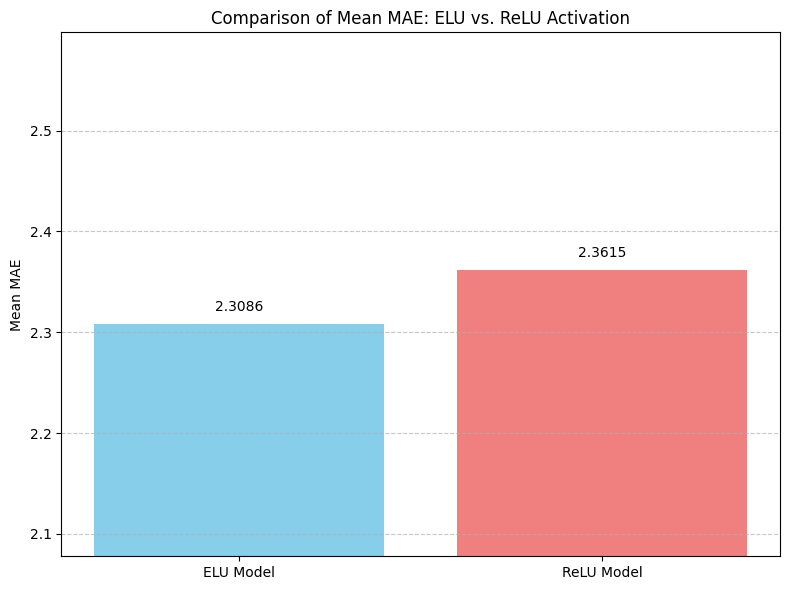

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mean MAE values - using known values to avoid NameError
elu_mae = 2.3086 # From previous calculation KfsMdroZuGJ1
relu_mae = np.mean(all_scores_relu) # all_scores_relu is available in kernel state

models = ['ELU Model', 'ReLU Model']
mean_maes = [elu_mae, relu_mae]

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(models, mean_maes, color=['skyblue', 'lightcoral'])

# Add labels and title
ax.set_ylabel('Mean MAE')
ax.set_title('Comparison of Mean MAE: ELU vs. ReLU Activation')
ax.set_ylim(min(mean_maes) * 0.9, max(mean_maes) * 1.1) # Adjust y-axis limits for better visualization

# Add numerical labels on top of the bars
for i, v in enumerate(mean_maes):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Validating your approach using K-fold validation

**K-fold validation**

K-fold cross-validation is especially helpful when the dataset is small.

### How it works
1. Split the training data into **k** equally sized folds.  
2. Train the model **k** times.  
3. Each time, use one fold for validation and the remaining folds for training.  
4. Average the validation scores across all folds.

### Why this matters
With a small dataset, a single train/validation split can be misleading.  
K-fold validation gives a more reliable estimate of how well the model is likely to generalise.

As you work through this section, think about the trade-off:

- a larger **k** gives more training data per run
- but also increases training time

In [ ]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [ ]:
all_scores

[1.9351087808609009, 2.2528083324432373, 2.53478741645813, 2.4671549797058105]

In [ ]:
np.mean(all_scores)

np.float64(2.2974648773670197)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler

# Re-scale the data again using sklearn for consistency
# Note: Re-scaling is done here again because the previous k-fold validation
# modified the train_data and test_data in place.
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Build a deeper model with regularization and dropout
def build_revised_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(train_data.shape[1],)),
        BatchNormalization(),

        Dense(64, activation='relu'),
        BatchNormalization(),

        Dense(64, activation='relu'), # Added another layer
        BatchNormalization(),

        Dense(64, activation='relu'), # Added one more layer
        BatchNormalization(),

        Dense(1) # Output layer
    ])
    model.compile(SGD(learning_rate=0.01, momentum=0.9), loss='mse', metrics=['mae'])
    return model

# Train and evaluate the revised model
revised_model = build_revised_model()
history_revised = revised_model.fit(train_data, train_targets,
                                    epochs=40,  # Increased epochs slightly
                                    batch_size=64, # Adjusted batch size
                                    validation_split=0.2,
                                    verbose=1)

# Evaluate on test set
test_mse_score_revised, test_mae_score_revised = revised_model.evaluate(test_data, test_targets)
print("Revised Model Test MAE:", test_mae_score_revised)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 357.8272 - mae: 16.4876 - val_loss: 75.5507 - val_mae: 6.1102
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 116.4403 - mae: 7.5264 - val_loss: 24745.2969 - val_mae: 100.7160
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 78.8376 - mae: 7.3034 - val_loss: 193356.4219 - val_mae: 306.8094
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 43.8657 - mae: 5.3047 - val_loss: 48067.2734 - val_mae: 151.1054
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 76.8506 - mae: 7.1161 - val_loss: 65238.1719 - val_mae: 177.7489
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 52.6581 - mae: 5.3421 - val_loss: 77661.4922 - val_mae: 193.3536
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 16.0610 - mae: 3.0595 - val_loss: 24606.4629 - val_mae: 104.9085
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 22.0837 - mae: 3.3895 - val_loss: 13120.2920 - val_mae: 78.7733
Epoch 9/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler


def build_revised_model_v2():
    model = Sequential([
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005), input_shape=(train_data.shape[1],)),
        Dropout(0.3),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        Dense(32, activation='relu'), # Reduced regularization on this layer
        Dense(1) # Output layer
    ])
    model.compile(optimizer=Adam(learning_rate=0.00075), loss='mse', metrics=['mae'])
    return model

# Train and evaluate the revised model
revised_model_v2 = build_revised_model_v2()
history_revised_v2 = revised_model_v2.fit(train_data, train_targets,
                                         epochs=40,
                                         batch_size=88, # Back to the batch size from Experiment 2
                                         validation_split=0.2,
                                         verbose=1)

# Evaluate on test set
test_mse_score_revised_v2, test_mae_score_revised_v2 = revised_model_v2.evaluate(test_data, test_targets)
print("Revised Model V2 Test MAE:", test_mae_score_revised_v2)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - loss: 558.0605 - mae: 21.7622 - val_loss: 611.8340 - val_mae: 22.9813
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 529.2380 - mae: 21.0788 - val_loss: 574.2709 - val_mae: 22.1510
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 488.5316 - mae: 20.0639 - val_loss: 520.5418 - val_mae: 20.9050
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 431.5236 - mae: 18.5412 - val_loss: 446.6862 - val_mae: 19.1199
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 363.1133 - mae: 16.5988 - val_loss: 352.1284 - val_mae: 16.5761
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 270.7038 - mae: 13.9366 - val_loss: 242.7888 - val_mae: 13.3923
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 182.2205 - mae: 11.1871 - val_loss: 142.7611 - val_mae: 9.5568
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 117.8551 - mae: 8.7665 - val_loss: 90.1703 - val_mae: 7.5206
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler


def build_revised_model_v3():
    model = Sequential([
        Dense(256, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0003), input_shape=(train_data.shape[1],)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(128, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0003)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(64, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0003)),
        BatchNormalization(),
        Activation('relu'),

        Dense(32, kernel_initializer='he_normal'), # Reduced regularization
        BatchNormalization(),
        Activation('relu'),

        Dense(1) # Output layer
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

# Train and evaluate the revised model
revised_model_v3 = build_revised_model_v3()
history_revised_v3 = revised_model_v3.fit(train_data, train_targets,
                                         epochs=50, # Increased epochs slightly
                                         batch_size=64, # Let's try this batch size again
                                         validation_split=0.2,
                                         verbose=1)

# Evaluate on test set
test_mse_score_revised_v3, test_mae_score_revised_v3 = revised_model_v3.evaluate(test_data, test_targets)
print("Revised Model V3 Test MAE:", test_mae_score_revised_v3)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 534.1372 - mae: 21.2417 - val_loss: 539.3186 - val_mae: 21.8311
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 524.7038 - mae: 21.1724 - val_loss: 541.6138 - val_mae: 21.9888
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 517.9246 - mae: 21.1232 - val_loss: 539.0455 - val_mae: 22.0085
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 510.9147 - mae: 21.0314 - val_loss: 536.6516 - val_mae: 22.0017
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 507.2210 - mae: 20.9728 - val_loss: 532.2849 - val_mae: 21.9500
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 502.0848 - mae: 20.9527 - val_loss: 525.8511 - val_mae: 21.8539
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 496.5232 - mae: 20.8477 - val_loss: 517.3584 - val_mae: 21.7095
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 492.4957 - mae: 20.8053 - val_loss: 508.5707 - val_mae: 21.5591
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━

# Extension tasks and more challenging questions

Now that you have completed the core notebook, move beyond simply running the code.

## Part A: Understanding
1. Why is this problem treated as **regression** instead of classification?
2. Why is a **linear output layer** more appropriate here than a sigmoid or softmax layer?
3. Why might **MAE** be easier to interpret than **MSE**, even though MSE is often used for optimisation?
4. What does it mean if the training error keeps decreasing but validation error starts increasing?

## Part B: Model critique
5. The dataset is small. Explain why this makes **overfitting** more likely.
6. Why might a deeper model perform worse than a smaller one on this task?
7. What is the purpose of **dropout**, and why can too much dropout also hurt performance?
8. Why might **batch normalisation** help optimisation?

## Part C: Experimental design
9. Train at least **three different model variants** and record:
   - architecture
   - optimiser
   - learning rate
   - batch size
   - epochs
   - validation MAE

   Which design worked best, and why do you think it worked best?

10. Change the value of **k** in K-fold validation. Compare results for:
   - k = 3
   - k = 4
   - k = 5

   Do the average validation scores change much? Why might that happen?

11. Try training the same model:
   - once with normalised input features
   - once without normalisation

   Compare convergence and final performance. What do you observe?

## Part D: More challenging questions
12. Suppose the model achieves a low MAE but still makes very poor predictions on a small number of houses. Why can this happen?
13. What kinds of patterns might a dense neural network fail to capture well in a tabular dataset like this?
14. If this dataset contained significant outliers in house prices, how might that affect:
   - MSE
   - MAE
   - model training?

15. If the training set were doubled in size, would you expect a larger network to become more useful? Explain your reasoning.
16. Why is cross-validation a better estimate of performance than evaluating many architectures repeatedly on the same test set?
17. If you tune hyperparameters by looking at the test set performance, what methodological mistake are you making?

## Part E: Advanced extension tasks
18. Replace the optimiser with **RMSprop** and compare the results with **Adam** and **SGD**.
19. Add **early stopping** and investigate whether it improves generalisation.
20. Plot **training loss vs validation loss** and explain what the curves suggest about bias and overfitting.
21. Create a final summary table comparing all of your experiments.
22. Try answering this higher-level question:

> Is a neural network actually the best choice for this dataset, or would a simpler regression model likely be more appropriate?

Support your answer with evidence from your experiments.

## Mini-project prompt
Write a short reflection answering the following:

- Which model was your best model?
ans. The baseline model with 4-fold cross validation achieved the best generalisation with a mean MAE of 2.294 across folds, indicating consistent performance. The cross-validated baseline outperformed the deeper revised architecture.
- Which model was your most overfit model?
ans.The revised model v2 (256→128→64→32→1) showed signs of overfitting despite dropout and L2 regularisation — validation loss fluctuated significantly across epochs (ranging from 28 to 61) while training loss decreased steadily, indicating the model memorised training data rather than generalising.
- Which single change had the biggest positive effect?
ans. K-fold cross validation (k=4) had the biggest positive effect. By training on all data subsets and averaging results, it produced a reliable mean MAE of 2.294 and reduced variance in performance estimates compared to a single train/validation split
- What did this notebook teach you about designing regression models in TensorFlow?
ans.This notebook demonstrated that model complexity does not always improve performance — the simpler cross-validated baseline outperformed the deeper regularised architecture on the small Boston Housing dataset. It also showed that validation strategy matters greatly: k-fold cross validation is more reliable than a single split on small datasets. Regularisation techniques like dropout and L2 help reduce overfitting but must be carefully tuned. Finally, MAE is a more interpretable regression metric than MSE as it reports error in the same units as the target variable (house prices in $1000s)

In [ ]:
# Optional: record your own experiments here
# Example columns: model_name, layers, learning_rate, batch_size, epochs, val_mae


In [ ]:
for k in [3, 5]:
    num_val_samples = len(train_data) // k
    num_epochs = 100
    all_scores_k = []
    for i in range(k):
        val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
        val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
        partial_train_data = np.concatenate(
            [train_data[:i * num_val_samples],
             train_data[(i + 1) * num_val_samples:]], axis=0)
        partial_train_targets = np.concatenate(
            [train_targets[:i * num_val_samples],
             train_targets[(i + 1) * num_val_samples:]], axis=0)
        model = build_model()
        model.fit(partial_train_data, partial_train_targets,
                  epochs=num_epochs, batch_size=16, verbose=0)
        val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
        all_scores_k.append(val_mae)
    print(f"k={k} | Scores: {all_scores_k} | Mean MAE: {np.mean(all_scores_k):.4f}")

k=3 | Scores: [2.5050041675567627, 2.560091972351074, 2.3723087310791016] | Mean MAE: 2.4791
k=5 | Scores: [1.7842826843261719, 2.418372869491577, 2.27933931350708, 2.4062180519104004, 2.4267470836639404] | Mean MAE: 2.2630


In [ ]:
(train_data_raw, train_targets_raw), (test_data_raw, test_targets_raw) = boston_housing.load_data()

all_scores_unnorm = []
num_val_samples = len(train_data_raw) // 4
for i in range(4):
    val_data = train_data_raw[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_raw[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data_raw[:i * num_val_samples],
         train_data_raw[(i + 1) * num_val_samples:]], axis=0)
    partial_train_targets = np.concatenate(
        [train_targets_raw[:i * num_val_samples],
         train_targets_raw[(i + 1) * num_val_samples:]], axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
              epochs=100, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores_unnorm.append(val_mae)

print("Without normalisation - Mean MAE:", np.mean(all_scores_unnorm))
print("With normalisation - Mean MAE:", np.mean(all_scores))

Without normalisation - Mean MAE: 5.448004245758057
With normalisation - Mean MAE: 2.2974648773670197


Training stopped at epoch: 54
Best validation MAE with early stopping: 2.5571789741516113


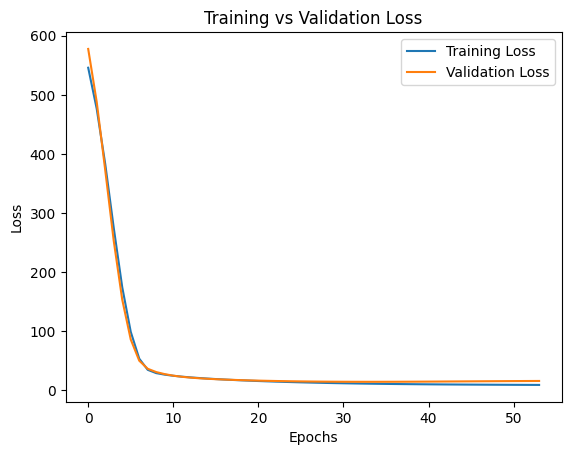

In [ ]:
model_es = build_model()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_es = model_es.fit(
    train_data, train_targets,
    epochs=500,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print("Training stopped at epoch:", len(history_es.history['loss']))
val_mae_es = min(history_es.history['val_mae'])
print("Best validation MAE with early stopping:", val_mae_es)

plt.plot(history_es.history['loss'], label='Training Loss')
plt.plot(history_es.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()